In [33]:
import numpy as np
import pandas as pd
from tensorflow import keras
import matplotlib.pyplot as plt
import tensorflow as tf


In [17]:
(X_train,y_train),(X_test,y_test) = keras.datasets.mnist.load_data()

In [18]:
X_train.shape

(60000, 28, 28)

In [19]:
X_test.shape

(10000, 28, 28)

In [20]:
X_train = X_train/255
X_test  = X_test/255

In [21]:
X_train_flat = X_train.reshape(len(X_train),28*28)
X_train_flat.shape


(60000, 784)

In [22]:
X_test_flat = X_test.reshape(len(X_test),28*28)
X_test_flat.shape

(10000, 784)

In [25]:
model = keras.Sequential([
    keras.layers.Dense(10,input_shape=(784,),activation = 'sigmoid')
])

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)



/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.fit(X_train_flat,y_train,epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8784 - loss: 0.4693
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9146 - loss: 0.3042
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9219 - loss: 0.2834
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9244 - loss: 0.2731
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9257 - loss: 0.2670


In [27]:
model.evaluate(X_test_flat,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9255 - loss: 0.2693


[0.2692916691303253, 0.9254999756813049]

In [28]:
y_predicted = model.predict(X_test_flat)
y_predicted[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([1.5900519e-02, 2.1794963e-07, 3.7854876e-02, 9.5404106e-01,
       1.8088506e-03, 7.5014360e-02, 1.5668338e-06, 9.9959272e-01,
       9.5454089e-02, 6.9353104e-01], dtype=float32)

In [30]:
y_predicted_labels = [np.argmax(i) for i in y_predicted]

In [31]:
y_predicted_labels[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [32]:
y_test[:5]

array([7, 2, 1, 0, 4], dtype=uint8)

In [34]:
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 962,    0,    1,    2,    0,    5,    6,    2,    2,    0],
       [   0, 1109,    3,    2,    0,    1,    4,    2,   14,    0],
       [  10,    9,  915,   20,    7,    3,   13,    9,   41,    5],
       [   4,    0,   17,  931,    1,   16,    3,    7,   20,   11],
       [   2,    1,    4,    1,  899,    0,   10,    3,    9,   53],
       [   9,    2,    2,   39,   10,  769,   17,    4,   32,    8],
       [  11,    3,    5,    2,    7,    8,  916,    2,    4,    0],
       [   2,    6,   22,    6,    8,    1,    0,  928,    4,   51],
       [   5,    7,    7,   21,    9,   18,   10,    5,  879,   13],
       [  10,    6,    1,   10,   15,    5,    0,    8,    7,  947]],
      dtype=int32)>

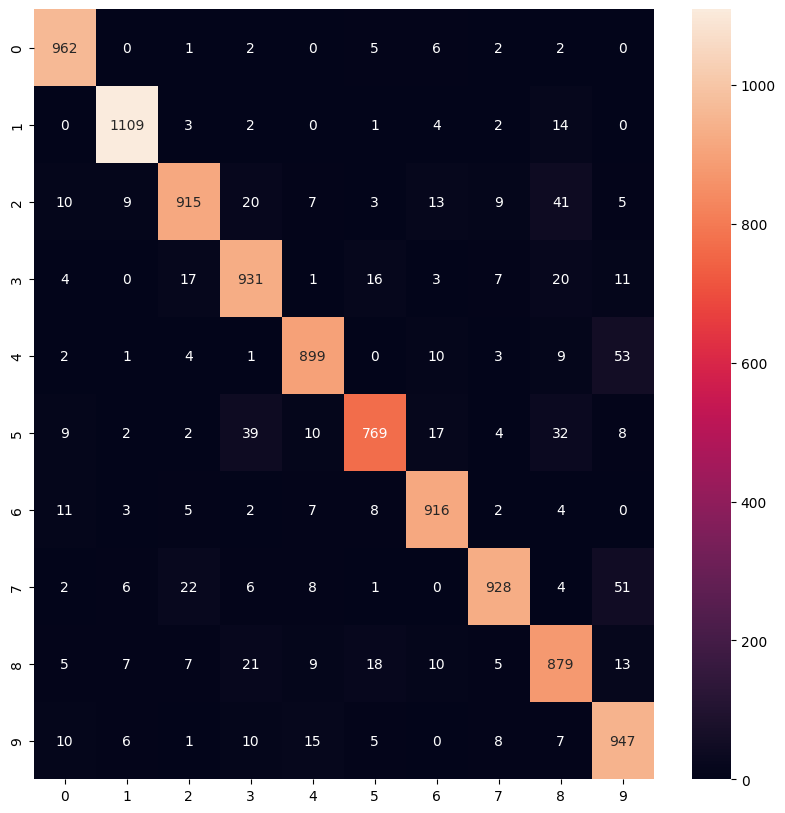

In [38]:
import seaborn as sns
plt.figure(figsize = (10,10))
sns.heatmap(cm,annot = True,fmt = "d")
plt.xlabel = "predicted"
plt.ylabel = "Truth_values"

In [42]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(100, input_shape=(784,), activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9247 - loss: 0.2665
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9646 - loss: 0.1216
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9740 - loss: 0.0847
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9804 - loss: 0.0650
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9849 - loss: 0.0500
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9873 - loss: 0.0414
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9896 - loss: 0.0334
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9916 - loss: 0.0274
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9930 - loss: 0.0228
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9940 - loss: 0.0196


In [43]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9778 - loss: 0.0844


[0.08439015597105026, 0.9778000116348267]

In [46]:
y_pred = model.predict(X_test)
y_pred_labels = [np.argmax(i) for i in y_pred]
confusion_m = tf.math.confusion_matrix(labels=y_test,predictions=y_pred_labels)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


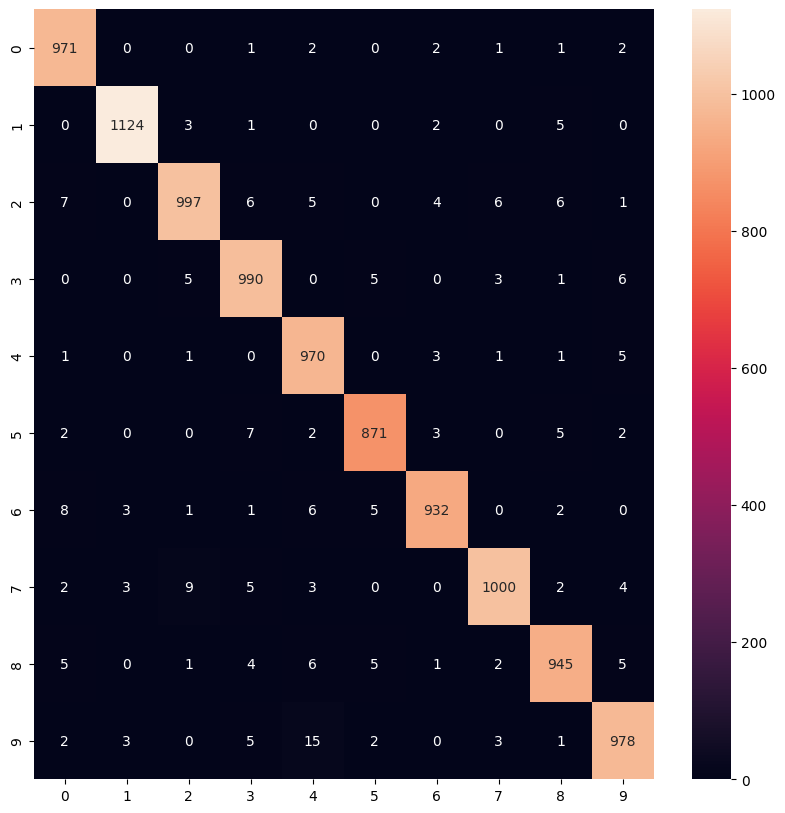

In [47]:
import seaborn as sns
plt.figure(figsize = (10,10))
sns.heatmap(confusion_m,annot = True,fmt = "d")
plt.xlabel = "predicted"
plt.ylabel = "Truth_values"